In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

TensorFlow version: 2.21.0
NumPy version: 2.5.2


In [30]:
print("TensorFlow is working!")

print(
    "GPU available:",
    len(tf.config.list_physical_devices("GPU")) > 0
)

print(
    "Available devices:",
    tf.config.list_physical_devices()
)

TensorFlow is working!
GPU available: False
Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [9]:
DATASET_PATH = r"C:\Users\HP\Desktop\archive"

TRAIN_PATH = os.path.join(DATASET_PATH, "train")
TEST_PATH = os.path.join(DATASET_PATH, "test")

print("Dataset path:", DATASET_PATH)
print("Train path:", TRAIN_PATH)
print("Test path:", TEST_PATH)

Dataset path: C:\Users\HP\Desktop\archive
Train path: C:\Users\HP\Desktop\archive\train
Test path: C:\Users\HP\Desktop\archive\test


In [31]:
print("Train folder exists:", os.path.exists(TRAIN_PATH))
print("Test folder exists:", os.path.exists(TEST_PATH))

Train folder exists: True
Test folder exists: True


In [11]:
class_names = sorted([
    folder
    for folder in os.listdir(TRAIN_PATH)
    if os.path.isdir(os.path.join(TRAIN_PATH, folder))
])

print("Emotion classes:")
for i, emotion in enumerate(class_names):
    print(i, "→", emotion)

NUM_CLASSES = len(class_names)

print("\nNumber of classes:", NUM_CLASSES)

Emotion classes:
0 → angry
1 → disgust
2 → fear
3 → happy
4 → neutral
5 → sad
6 → surprise

Number of classes: 7


In [12]:
train_counts = {}
test_counts = {}

for emotion in class_names:

    train_folder = os.path.join(TRAIN_PATH, emotion)
    test_folder = os.path.join(TEST_PATH, emotion)

    train_counts[emotion] = len([
        f for f in os.listdir(train_folder)
        if os.path.isfile(os.path.join(train_folder, f))
    ])

    test_counts[emotion] = len([
        f for f in os.listdir(test_folder)
        if os.path.isfile(os.path.join(test_folder, f))
    ])

print("TRAIN DATA")
print("=" * 40)

for emotion, count in train_counts.items():
    print(f"{emotion:10s}: {count}")

print("\nTEST DATA")
print("=" * 40)

for emotion, count in test_counts.items():
    print(f"{emotion:10s}: {count}")

TRAIN DATA
angry     : 3995
disgust   : 436
fear      : 4097
happy     : 7215
neutral   : 4965
sad       : 4830
surprise  : 3171

TEST DATA
angry     : 958
disgust   : 111
fear      : 1024
happy     : 1774
neutral   : 1233
sad       : 1247
surprise  : 831


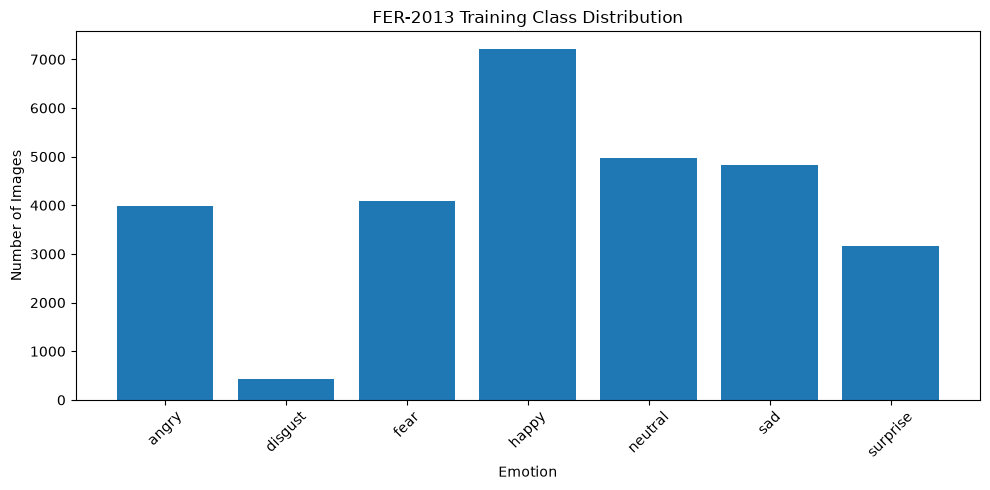

In [13]:
plt.figure(figsize=(10, 5))

plt.bar(
    train_counts.keys(),
    train_counts.values()
)

plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.title("FER-2013 Training Class Distribution")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

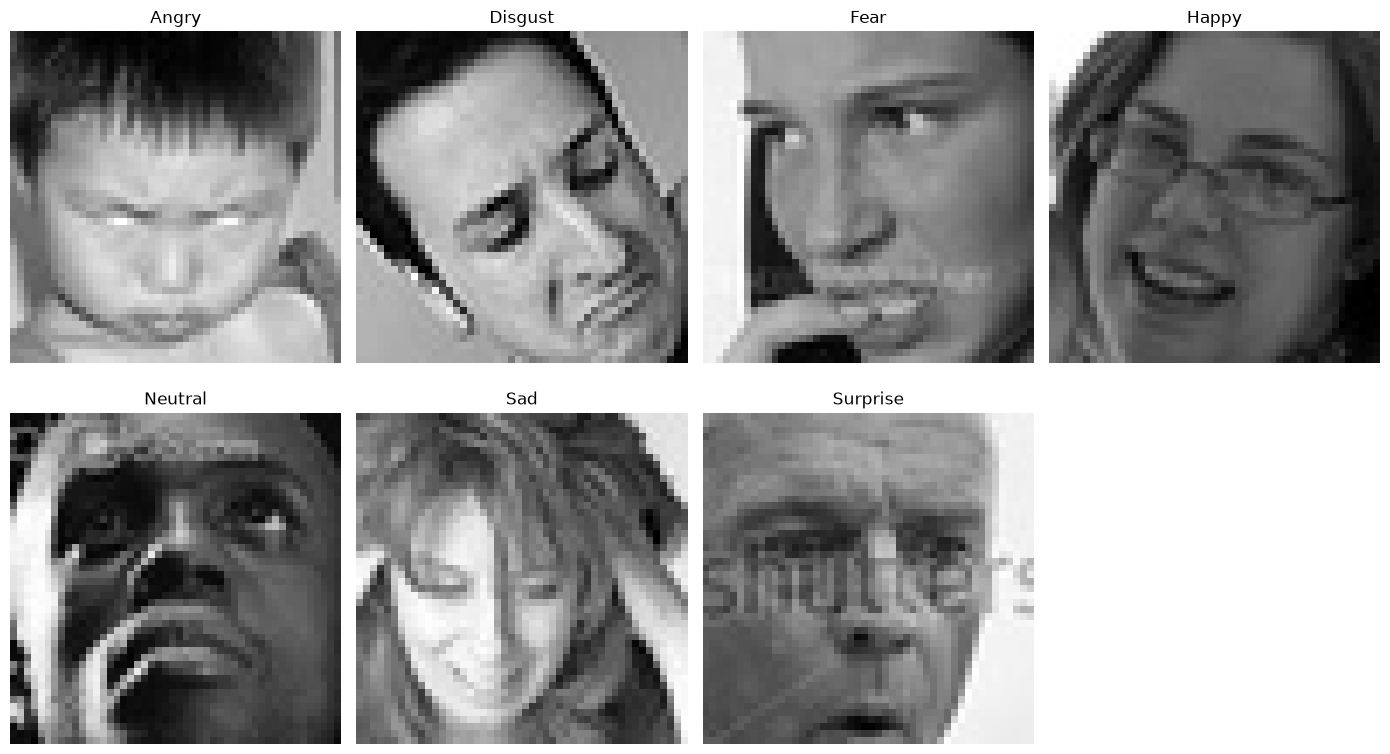

In [14]:
plt.figure(figsize=(14, 8))

for i, emotion in enumerate(class_names):

    emotion_folder = os.path.join(
        TRAIN_PATH,
        emotion
    )

    image_files = os.listdir(emotion_folder)

    image_path = os.path.join(
        emotion_folder,
        image_files[0]
    )

    image = plt.imread(image_path)

    plt.subplot(2, 4, i + 1)

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.title(emotion.capitalize())

    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
IMG_SIZE = 48
BATCH_SIZE = 64

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: 48
Batch size: 64


In [20]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,

    rotation_range=15,

    width_shift_range=0.1,

    height_shift_range=0.1,

    zoom_range=0.1,

    horizontal_flip=True,

    validation_split=0.20
)


test_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0
)

In [21]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,

    target_size=(IMG_SIZE, IMG_SIZE),

    color_mode="grayscale",

    class_mode="categorical",

    batch_size=BATCH_SIZE,

    subset="training",

    shuffle=True,

    seed=42
)

print("\nTraining samples:", train_generator.samples)

Found 22968 images belonging to 7 classes.

Training samples: 22968


In [22]:
validation_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,

    target_size=(IMG_SIZE, IMG_SIZE),

    color_mode="grayscale",

    class_mode="categorical",

    batch_size=BATCH_SIZE,

    subset="validation",

    shuffle=False,

    seed=42
)

print("\nValidation samples:", validation_generator.samples)

Found 5741 images belonging to 7 classes.

Validation samples: 5741


In [23]:
test_generator = test_datagen.flow_from_directory(
    TEST_PATH,

    target_size=(IMG_SIZE, IMG_SIZE),

    color_mode="grayscale",

    class_mode="categorical",

    batch_size=BATCH_SIZE,

    shuffle=False
)

print("\nTest samples:", test_generator.samples)

Found 7178 images belonging to 7 classes.

Test samples: 7178


In [24]:
print(train_generator.class_indices)

{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [25]:
model = models.Sequential([

    layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 1)
    ),

    # -------------------------
    # Block 1
    # -------------------------

    layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    layers.Dropout(0.25),


    # -------------------------
    # Block 2
    # -------------------------

    layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    layers.Dropout(0.25),


    # -------------------------
    # Block 3
    # -------------------------

    layers.Conv2D(
        128,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.Conv2D(
        128,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    layers.Dropout(0.25),


    # -------------------------
    # Classification
    # -------------------------

    layers.Flatten(),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.Dropout(0.5),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 48, 48, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 48, 48, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 48, 48, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 48, 48, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 24, 24, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 24, 24, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 24, 24, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 24, 24, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 12, 12, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 1,470,951 (5.61 MB)

 Trainable params: 1,469,543 (5.61 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [26]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [27]:
callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        "best_emotion_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks configured.")

Callbacks configured.


In [32]:
EPOCHS = 30

history = model.fit(
    train_generator,

    validation_data=validation_generator,

    epochs=EPOCHS,

    callbacks=callbacks
)

Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.4817 - loss: 1.3487
Epoch 1: val_accuracy improved from 0.40498 to 0.48789, saving model to best_emotion_model.keras

Epoch 1: finished saving model to best_emotion_model.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 117s 326ms/step - accuracy: 0.4817 - loss: 1.3487 - val_accuracy: 0.4879 - val_loss: 1.3338 - learning_rate: 0.0010
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.5106 - loss: 1.2894
Epoch 2: val_accuracy improved from 0.48789 to 0.52970, saving model to best_emotion_model.keras

Epoch 2: finished saving model to best_emotion_model.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 119s 332ms/step - accuracy: 0.5106 - loss: 1.2894 - val_accuracy: 0.5297 - val_loss: 1.2379 - learning_rate: 0.0010
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.5251 - loss: 1.2535
Epoch 3: val_accuracy did not improve from 0.52970
359/359 ━━━━━━━━━━━━━━━━━━━━ 120s 335ms/step - accuracy: 0.5251 - loss: 1.2535 - 

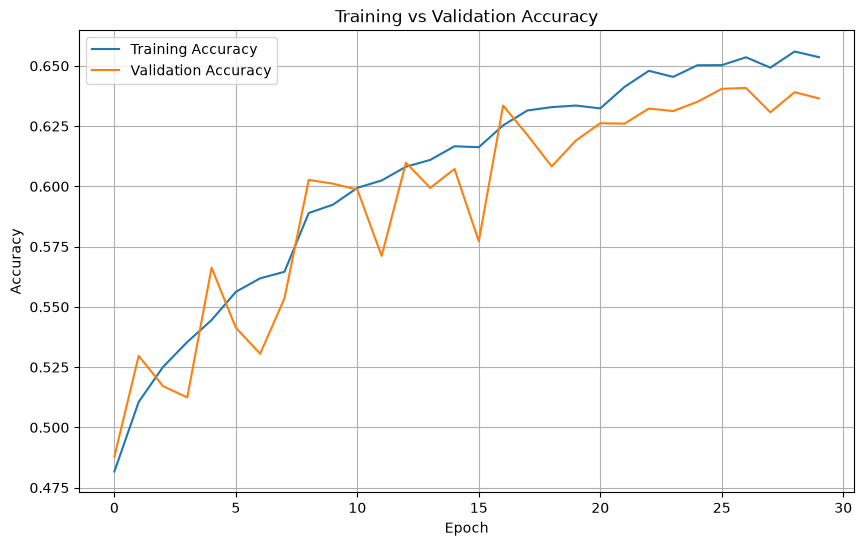

In [33]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()

plt.grid()

plt.show()

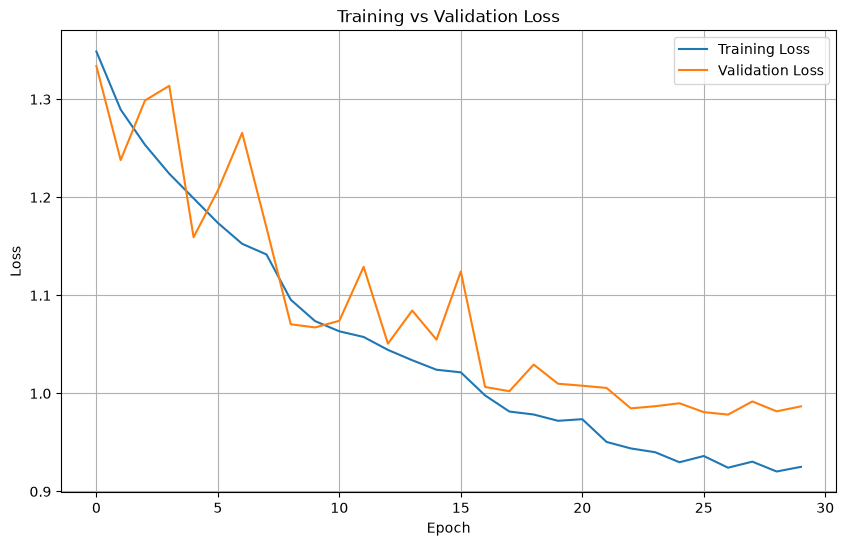

In [34]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()

plt.grid()

plt.show()

In [35]:
test_loss, test_accuracy = model.evaluate(
    test_generator
)

print(
    f"Test Loss: {test_loss:.4f}"
)

print(
    f"Test Accuracy: {test_accuracy * 100:.2f}%"
)

113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.6473 - loss: 0.9634
Test Loss: 0.9634
Test Accuracy: 64.73%


In [36]:
test_generator.reset()

predictions = model.predict(
    test_generator,
    verbose=1
)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

true_classes = test_generator.classes

print("Predictions generated.")

113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step
Predictions generated.


In [37]:
print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       angry       0.56      0.59      0.58       958
     disgust       0.71      0.27      0.39       111
        fear       0.54      0.35      0.42      1024
       happy       0.86      0.87      0.86      1774
     neutral       0.54      0.73      0.62      1233
         sad       0.56      0.48      0.51      1247
    surprise       0.72      0.79      0.75       831

    accuracy                           0.65      7178
   macro avg       0.64      0.58      0.59      7178
weighted avg       0.65      0.65      0.64      7178



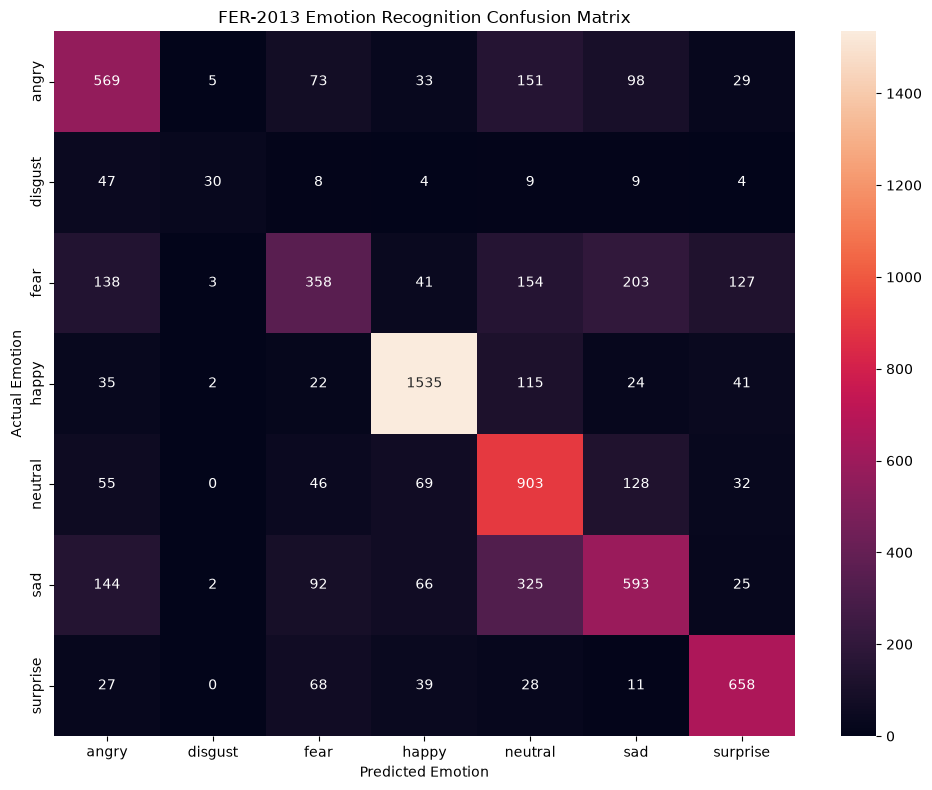

In [38]:
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Emotion")

plt.ylabel("Actual Emotion")

plt.title(
    "FER-2013 Emotion Recognition Confusion Matrix"
)

plt.tight_layout()

plt.show()

In [39]:
MODEL_PATH = "emotion_model.keras"

model.save(MODEL_PATH)

print(
    "Model saved successfully:"
)

print(
    os.path.abspath(MODEL_PATH)
)

Model saved successfully:
C:\Users\HP\AppData\Local\Programs\Python\Python312\Scripts\emotion_model.keras


In [40]:
loaded_model = tf.keras.models.load_model(
    MODEL_PATH
)

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [41]:
import random

emotion = random.choice(class_names)

emotion_folder = os.path.join(
    TEST_PATH,
    emotion
)

image_file = random.choice(
    os.listdir(emotion_folder)
)

image_path = os.path.join(
    emotion_folder,
    image_file
)

print("Actual emotion:", emotion)
print("Image:", image_path)

Actual emotion: sad
Image: C:\Users\HP\Desktop\archive\test\sad\PublicTest_81549573.jpg


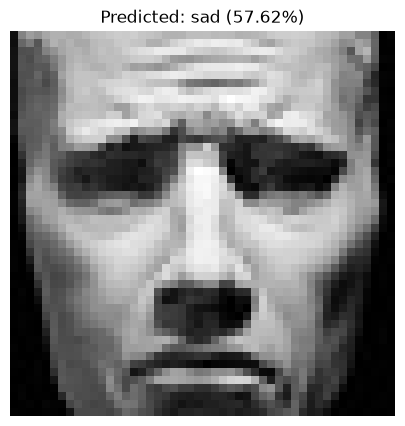

Actual: sad
Predicted: sad
Confidence: 57.62%


In [42]:
from tensorflow.keras.utils import load_img, img_to_array

image = load_img(
    image_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale"
)

image_array = img_to_array(image)

image_array = image_array / 255.0

image_array = np.expand_dims(
    image_array,
    axis=0
)

prediction = loaded_model.predict(
    image_array,
    verbose=0
)

predicted_index = np.argmax(
    prediction[0]
)

predicted_emotion = class_names[
    predicted_index
]

confidence = prediction[0][
    predicted_index
] * 100

plt.figure(figsize=(5, 5))

plt.imshow(
    image_array[0].squeeze(),
    cmap="gray"
)

plt.title(
    f"Predicted: {predicted_emotion} "
    f"({confidence:.2f}%)"
)

plt.axis("off")

plt.show()

print("Actual:", emotion)
print("Predicted:", predicted_emotion)
print(f"Confidence: {confidence:.2f}%")

In [2]:
!pip install opencv-python==4.10.0.84

   ---------------------------------------- 0.0/38.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.8 MB ? eta -:--:--
    --------------------------------------- 0.5/38.8 MB 985.5 kB/s eta 0:00:39
   - -------------------------------------- 1.0/38.8 MB 1.5 MB/s eta 0:00:26
   - -------------------------------------- 1.6/38.8 MB 1.7 MB/s eta 0:00:22
   - -------------------------------------- 1.8/38.8 MB 1.8 MB/s eta 0:00:21
   -- ------------------------------------- 2.1/38.8 MB 1.7 MB/s eta 0:00:23
   -- ------------------------------------- 2.6/38.8 MB 1.7 MB/s eta 0:00:22
   --- ------------------------------------ 3.1/38.8 MB 1.8 MB/s eta 0:00:20
   --- ------------------------------------ 3.7/38.8 MB 1.9 MB/s eta 0:00:19
   ---- ----------------------------------- 4.2/38.8 MB 1.9 MB/s eta 0:00:19
   ---- -----------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
import cv2

print("OpenCV version:", cv2.__version__)
print("CascadeClassifier:", hasattr(cv2, "CascadeClassifier"))
print("cv2 location:", cv2.__file__)


OpenCV version: 4.10.0
CascadeClassifier: True
cv2 location: C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\cv2\__init__.py


In [44]:
face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

if face_detector.empty():
    print("ERROR: Face detector could not be loaded.")
else:
    print("Face detector loaded successfully.")

Face detector loaded successfully.


In [45]:
face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

if face_detector.empty():
    print("ERROR: Face detector could not be loaded.")

else:
    print("Face detector loaded successfully.")

Face detector loaded successfully.


In [6]:
import numpy as np
import cv2
import tensorflow as tf
import cv2
import numpy as np
import tensorflow as np
from collections import Counter  # For counting predictions

# ----------------------------------
# Load trained model
# ----------------------------------

emotion_model = tf.keras.models.load_model("emotion_model.keras")

# ----------------------------------
# Emotion labels
# ----------------------------------

emotion_labels = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "sad",
    "surprise",
    "neutral"
]

# ----------------------------------
# Load face detector
# ----------------------------------

face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# ----------------------------------
# Start webcam
# ----------------------------------

camera = cv2.VideoCapture(0)

if not camera.isOpened():
    print("ERROR: Could not open webcam.")
else:
    print("Webcam started.")
    print("Press Q or ESC to quit.")

# ----------------------------------
# NEW: Store all predictions
# ----------------------------------

predictions_list = []  # List to store all emotions predicted
confidence_list = []   # List to store all confidence scores
frame_count = 0        # Count total frames processed

# ----------------------------------
# Real-time loop
# ----------------------------------

while camera.isOpened():
    success, frame = camera.read()

    if not success:
        print("Could not read camera frame.")
        break

    # Mirror image
    frame = cv2.flip(frame, 1)

    # Convert to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect faces
    faces = face_detector.detectMultiScale(
        gray,
        scaleFactor=1.3,
        minNeighbors=5,
        minSize=(50, 50)
    )

    # Process every detected face
    for (x, y, w, h) in faces:
        # Extract face
        face = gray[y:y+h, x:x+w]

        # Resize
        face = cv2.resize(face, (48, 48))

        # Normalize
        face = face.astype("float32") / 255.0

        # Reshape
        face = np.expand_dims(face, axis=-1)
        face = np.expand_dims(face, axis=0)

        # Predict
        prediction = emotion_model.predict(face, verbose=0)

        # Get predicted class
        emotion_index = np.argmax(prediction[0])
        emotion = emotion_labels[emotion_index]
        confidence = prediction[0][emotion_index] * 100

        # ----------------------------------
        # NEW: Store predictions
        # ----------------------------------
        predictions_list.append(emotion)
        confidence_list.append(confidence)
        frame_count += 1

        # Draw face rectangle
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

        # Display emotion
        text = f"{emotion.capitalize()} {confidence:.1f}%"
        cv2.putText(
            frame,
            text,
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 0),
            2
        )

    # Display camera
    cv2.imshow("Real-Time Facial Emotion Recognition", frame)

    # Check for Q or ESC
    key = cv2.waitKey(1) & 0xFF
    if key == ord('q') or key == ord('Q') or key == 27:
        print("Quitting...")
        break

# ----------------------------------
# Cleanup
# ----------------------------------

camera.release()
cv2.destroyAllWindows()
print("Camera stopped.")

# ==========================================
# NEW: FINAL DECISION OUTPUT
# ==========================================

print("\n" + "=" * 60)
print("📊 FINAL EMOTION ANALYSIS REPORT")
print("=" * 60)

if len(predictions_list) == 0:
    print("❌ No faces were detected during this session.")
else:
    # 1. Most common emotion
    most_common = Counter(predictions_list).most_common(1)[0]
    final_emotion = most_common[0]
    count = most_common[1]
    
    # 2. All emotion counts
    emotion_counts = Counter(predictions_list)
    
    # 3. Average confidence
    avg_confidence = sum(confidence_list) / len(confidence_list) if confidence_list else 0
    
    print(f"\n📸 Frames Processed: {frame_count}")
    print(f"🎯 Most Common Emotion: {final_emotion.upper()}")
    print(f"   Detected {count} times out of {frame_count} frames ({count/frame_count*100:.1f}%)")
    print(f"📊 Average Confidence: {avg_confidence:.1f}%")
    
    print("\n📋 Detailed Breakdown:")
    print("-" * 40)
    for emotion in emotion_labels:
        if emotion in emotion_counts:
            percentage = (emotion_counts[emotion] / frame_count) * 100
            bar = "█" * int(percentage / 2)  # Simple bar chart
            print(f"   {emotion.capitalize():10s}: {emotion_counts[emotion]:4d} frames ({percentage:5.1f}%) {bar}")
        else:
            print(f"   {emotion.capitalize():10s}: 0 frames (0.0%)")
    
    print("\n" + "=" * 60)
    print(f"🏆 FINAL DECISION: {final_emotion.upper()} (Based on {frame_count} frames)")
    print("=" * 60)

# ----------------------------------
# Optional: Save report to file
# ----------------------------------

with open("emotion_analysis_report.txt", "w") as f:
    f.write("=" * 60 + "\n")
    f.write("EMOTION ANALYSIS REPORT\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Frames Processed: {frame_count}\n")
    if frame_count > 0:
        f.write(f"Most Common Emotion: {final_emotion.upper()}\n")
        f.write(f"Average Confidence: {avg_confidence:.1f}%\n\n")
        f.write("Detailed Breakdown:\n")
        for emotion in emotion_labels:
            if emotion in emotion_counts:
                f.write(f"   {emotion}: {emotion_counts[emotion]} frames\n")
    f.write("\n" + "=" * 60 + "\n")

print("\n📁 Report saved to: emotion_analysis_report.txt")

Webcam started.
Press Q or ESC to quit.
Quitting...
Camera stopped.

📊 FINAL EMOTION ANALYSIS REPORT

📸 Frames Processed: 341
🎯 Most Common Emotion: SAD
   Detected 228 times out of 341 frames (66.9%)
📊 Average Confidence: 75.5%

📋 Detailed Breakdown:
----------------------------------------
   Angry     : 0 frames (0.0%)
   Disgust   : 0 frames (0.0%)
   Fear      : 0 frames (0.0%)
   Happy     :  101 frames ( 29.6%) ██████████████
   Sad       :  228 frames ( 66.9%) █████████████████████████████████
   Surprise  :    9 frames (  2.6%) █
   Neutral   :    3 frames (  0.9%) 

🏆 FINAL DECISION: SAD (Based on 341 frames)

📁 Report saved to: emotion_analysis_report.txt
